In [10]:
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
v1 = pd.read_csv("../results/timings/simulation_timings_v1.csv")
v2 = pd.read_csv("../results/timings/simulation_timings_v2.csv")

output = (
    pd.concat([v1, v2], keys=["naive", "optimized"])
    .reset_index(level=0)
    .rename(columns={"level_0": "implementation"})
)

,implementation,n,N,n_sim,time_seconds
0,naive,4,40,100,0.168107
1,naive,4,40,500,0.793153
2,naive,4,40,1000,1.620070
3,naive,4,40,2000,3.225839
4,naive,4,100,100,0.157226
...,...,...,...,...,...
31,optimized,20,500,2000,2.313651
32,optimized,20,2000,100,0.182997
33,optimized,20,2000,500,1.275108
34,optimized,20,2000,1000,1.871827


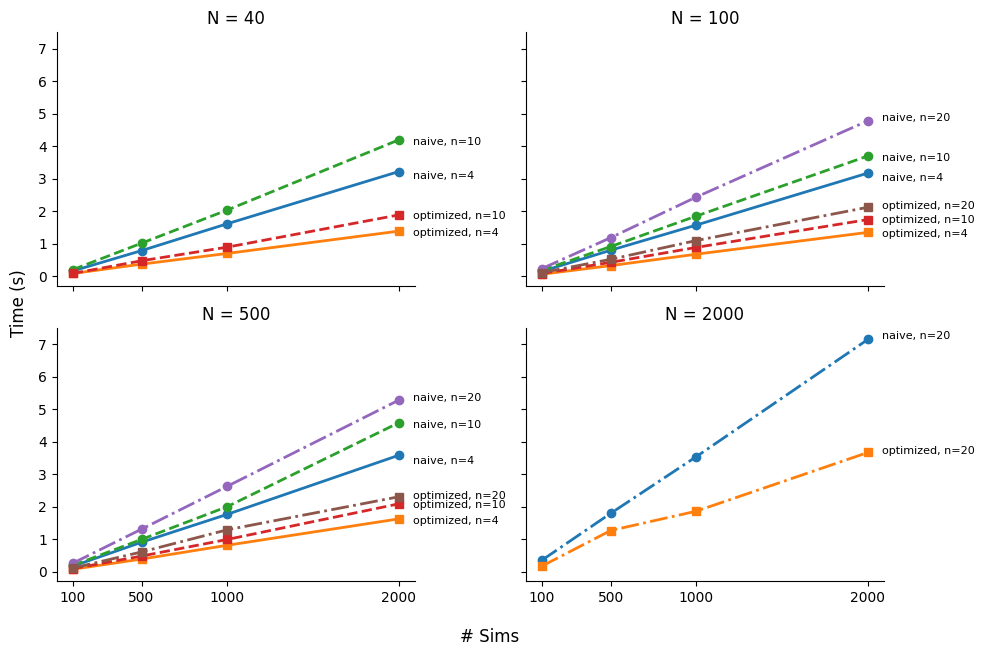

In [ ]:
import math
import numpy as np
from matplotlib.ticker import LogFormatterMathtext, FixedLocator

# === config ===
row_var = "N"  # facets
col_var = "n"  # linestyle
impl_var = "implementation"  # color+marker
x_max_pad = None  # e.g., 4000 to extend to the right; or None for auto

# ---- prep unique levels ----
row_vals = sorted(output[row_var].unique())
col_vals = sorted(output[col_var].unique())
impl_levels = sorted(output[impl_var].unique(), key=lambda s: str(s).lower())

# ---- style maps ----
linestyles = ["solid", "dashed", "dashdot", "dotted"]  # up to 4
ls_map = {cv: linestyles[i % len(linestyles)] for i, cv in enumerate(col_vals)}
markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]  # cycle markers for impls
impl_mark = {impl: markers[i % len(markers)] for i, impl in enumerate(impl_levels)}


# ---- inline end-label helper (x & y nudges) ----
def label_right(ax, x, y, text, dy=0.0):
    xmin, xmax = ax.get_xlim()
    dx = 0.02 * (xmax - xmin) if xmax > xmin else 0.0
    ax.text(x + dx, y * (1 + dy), f"  {text}", va="center", fontsize=8, clip_on=False)


# ---- paginate into 2x2 pages ----
panels_per_fig = 4
num_pages = math.ceil(len(row_vals) / panels_per_fig)

for page in range(num_pages):
    rows_this_page = row_vals[page * panels_per_fig : (page + 1) * panels_per_fig]

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    axes = np.array(axes).reshape(2, 2)

    seen_cols = set()
    page_df = output[output[row_var].isin(rows_this_page)]

    # union of x levels on this page (FORCE ticks here)
    x_levels = sorted(page_df["n_sim"].unique())

    # ---- draw each panel ----
    for k, rv in enumerate(rows_this_page):
        i, j = divmod(k, 2)
        ax = axes[i, j]

        sub_r = output[output[row_var] == rv].copy()
        ax.set_title(f"{row_var} = {rv}")

        sub_r.sort_values(["n_sim", impl_var, col_var], inplace=True)

        for cv in col_vals:
            sub_rc = sub_r[sub_r[col_var] == cv]
            if sub_rc.empty:
                continue
            seen_cols.add(cv)

            # small vertical offsets for end labels by linestyle index
            dy = (list(ls_map.values()).index(ls_map[cv]) - 1.5) * 0.03  # around ±0.045

            for impl, group in sub_rc.groupby(impl_var):
                group = group.sort_values("n_sim")

                ax.plot(
                    group["n_sim"],
                    group["time_seconds"],
                    linestyle=ls_map[cv],
                    marker=impl_mark[impl],
                    linewidth=2,
                    label=None,
                )

                # inline end label
                x_end = group["n_sim"].iloc[-1]
                y_end = group["time_seconds"].iloc[-1]
                label_right(ax, x_end, y_end, f"{impl}, {col_var}={cv}", dy=dy)

        # ---- FORCE numeric ticks at your actual values ----
        ax.xaxis.set_major_locator(FixedLocator(x_levels))
        ax.set_xticklabels([str(v) for v in x_levels])

        # optional: extend to a fixed right edge (e.g., 4000)
        if x_max_pad is not None and len(x_levels):
            ax.set_xlim(min(x_levels), x_max_pad)

    # hide any unused panels on last page
    if len(rows_this_page) < panels_per_fig:
        for k in range(len(rows_this_page), panels_per_fig):
            i, j = divmod(k, 2)
            axes[i, j].axis("off")

    # ---- shared log-y ticks (force decades incl. 10^1), grids, despine, margins ----
    y_all = page_df["time_seconds"]
    y_all = y_all[y_all > 0]
    if len(y_all):
        decade_lo = int(np.floor(np.log10(y_all.min())))
        decade_hi = int(np.ceil(np.log10(y_all.max())))
        major_ticks = 10.0 ** np.arange(
            decade_lo, decade_hi + 1
        )  # includes 10^1 if in range
    else:
        major_ticks = 10.0 ** np.arange(-1, 4)  # fallback

    for ax in axes.ravel():
        if not ax.has_data():
            continue
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(FixedLocator(major_ticks))
        ax.yaxis.set_major_formatter(LogFormatterMathtext())

        ax.minorticks_on()
        ax.grid(True, which="major", alpha=0.30)
        ax.grid(True, which="minor", alpha=0.15)

        # Despine top/right and add right margin for labels
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.margins(x=0.05)

    # ---- shared figure labels ----
    fig.supxlabel("# Sims")
    fig.supylabel("Time (s)")

    fig.tight_layout(rect=[0, 0, 1, 0.94])  # space for legend
    plt.show()